## Research Question
Has there been a discursive shift in EU-funded project descriptions from climate-oriented narratives to security- and resilience-oriented narratives?

Research plan:
* Inspect keyword frequency trends over the years (e.g., “climate”, “sustainability” vs. “security”, “resilience”, “strategic autonomy”)
* Topic modeling (BERTopic) to identify thematic clusters per year. Then compare thematic clusters over the years.
* Combining bag-of-words frequency analysis with sentence embedding-based topic modelling via BERTopic. 

To obtain results, I use the project's keywords, titles and descriptions (columns "metadata_title", "metadata_freeKeywords" and "metadata_objective". The data is obtained with the SEDIA-API-FETCHER.)

In [1]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import plotly.express as px
import nltk
import sys
import subprocess
import matplotlib.ticker as mticker
import importlib

from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('wordnet')
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")



/Users/kimwilmink/anaconda3/envs/thesis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
with open("data/corpus.json", encoding="utf-8") as file:
    corpus_records = json.load(file)

# Keep project metadata in a DataFrame and the corresponding texts in a list.
# Both retain the same row order, which is required by the yearly analyses below.
data = pd.DataFrame(corpus_records)
corpus = data["_combined_text"].fillna("").astype(str).tolist()

print(f"Loaded {len(corpus):,} project texts")

Loaded 58,780 project texts


In [3]:
# Setting colors for plots
BLUE = "#2a78d6"
ORANGE = "#eb6834"
AQUA = "#1baf7a"
GRAY = "#898781"

## Bag of Words

In [4]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text.lower())
    return " ".join(
        lemmatizer.lemmatize(token) 
        for token in tokens
        if token.isalpha()
    )

# Apply before fitting the vectorizers
lemmatized_corpus = [lemmatize_text(doc) for doc in corpus]

In [5]:
#  1. BAG-OF-WORDS (word frequency counts) 
count_vec = CountVectorizer(
    min_df=2,               # ignore terms that appear in fewer than 2 docs
    max_features=500,       # keep only the top 500 terms
)

bow_matrix = count_vec.fit_transform(lemmatized_corpus)
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=count_vec.get_feature_names_out()
)

# Overall word frequencies across the whole lemmatized corpus
word_freq = bow_df.sum().sort_values(ascending=False)


In [6]:
print(word_freq.head(100))

system        53105
technology    43021
cell          32404
energy        31131
process       29778
              ...  
area          11400
property      11386
large         11305
state         11290
industrial    11282
Length: 100, dtype: int64


#### Frequency trends by project start year

Raw word counts cannot be compared directly across years because the number of projects and the amount of text differ. Therefore, the graphs below report occurrences per 10,000 words. The analysis uses project start year because it best represents when a project's justification entered the Horizon 2020 portfolio.

The term lists operationalise the two narratives in the research question. They should be treated as an explicit, reproducible dictionary rather than as a complete definition of either discourse. Years with fewer than 100 projects are excluded from the plots because their frequencies are unstable.

In [7]:
# Extract a year from each project's start date.
data["start_year"] = pd.to_datetime(
    data["startdate"], errors="coerce", utc=True
).dt.year

# Dictionary-based operationalisation of the narratives in the research question.
# These forms match the lemmatised corpus produced above.
NARRATIVE_TERMS = {
    "Climate-oriented": [
        "climate", "climate change", "sustainability", "sustainable",
        "environment", "environmental", "renewable", "decarbonisation",
        "decarbonization", "green transition", "climate justice", "global warming",
        "carbon footprint", "carbon neutrality", "carbon neutral", "recycle", "circular economy"
    ],
    "Security/resilience-oriented": [
        "security", "resilience", "resilient", "defence", "defense",
        "strategic autonomy", "autonomy", "sovereignty", "energy security",
        "preparedness", "vulnerability", "threat", "vulnerable", "self-sufficiency",
        "self-sufficient", "self-reliance", "self-reliant", "supply chain",
        "critical infrastructure", "securitize", "securitization", "geopolitical", "geostrategic"
    ],
}

term_to_narrative = {
    term: narrative
    for narrative, terms in NARRATIVE_TERMS.items()
    for term in terms
}

# Use a dedicated vectorizer so theoretically relevant terms are not removed by
# the max_features=500 setting used for the exploratory word-frequency table.
trend_vectorizer = CountVectorizer(
    vocabulary=list(term_to_narrative),
    ngram_range=(1, 2),
)
trend_matrix = trend_vectorizer.fit_transform(lemmatized_corpus)

term_counts = pd.DataFrame(
    trend_matrix.toarray(),
    columns=trend_vectorizer.get_feature_names_out(),
    index=data.index,
)

# Denominator used to compare years with different amounts of text.
data["token_count"] = [len(document.split()) for document in lemmatized_corpus]
term_counts["start_year"] = data["start_year"]
term_counts["token_count"] = data["token_count"]

In [8]:
# Aggregate term counts and denominators by year.
terms = list(term_to_narrative)
annual_counts = term_counts.groupby("start_year")[terms].sum()
annual_tokens = term_counts.groupby("start_year")["token_count"].sum()
annual_projects = data.groupby("start_year").size()

# Occurrences per 10,000 words.
annual_frequency = annual_counts.div(annual_tokens, axis=0) * 10_000
term_frequency = annual_frequency.copy()

# Avoid drawing conclusions from years represented by only a handful of projects.
MIN_PROJECTS_PER_YEAR = 100
included_years = annual_projects[annual_projects >= MIN_PROJECTS_PER_YEAR].index
annual_frequency = annual_frequency.loc[included_years]

year_summary = pd.DataFrame({
    "projects": annual_projects.loc[included_years],
    "analysed_words": annual_tokens.loc[included_years],
})
display(year_summary)

,projects,analysed_words
start_year,,
2014,882,145136
2015,4849,820703
2016,5142,873563
2017,4810,824228
2018,5324,911956
2019,5493,942073
2020,4588,793673
2021,3715,641892
2022,5149,878703


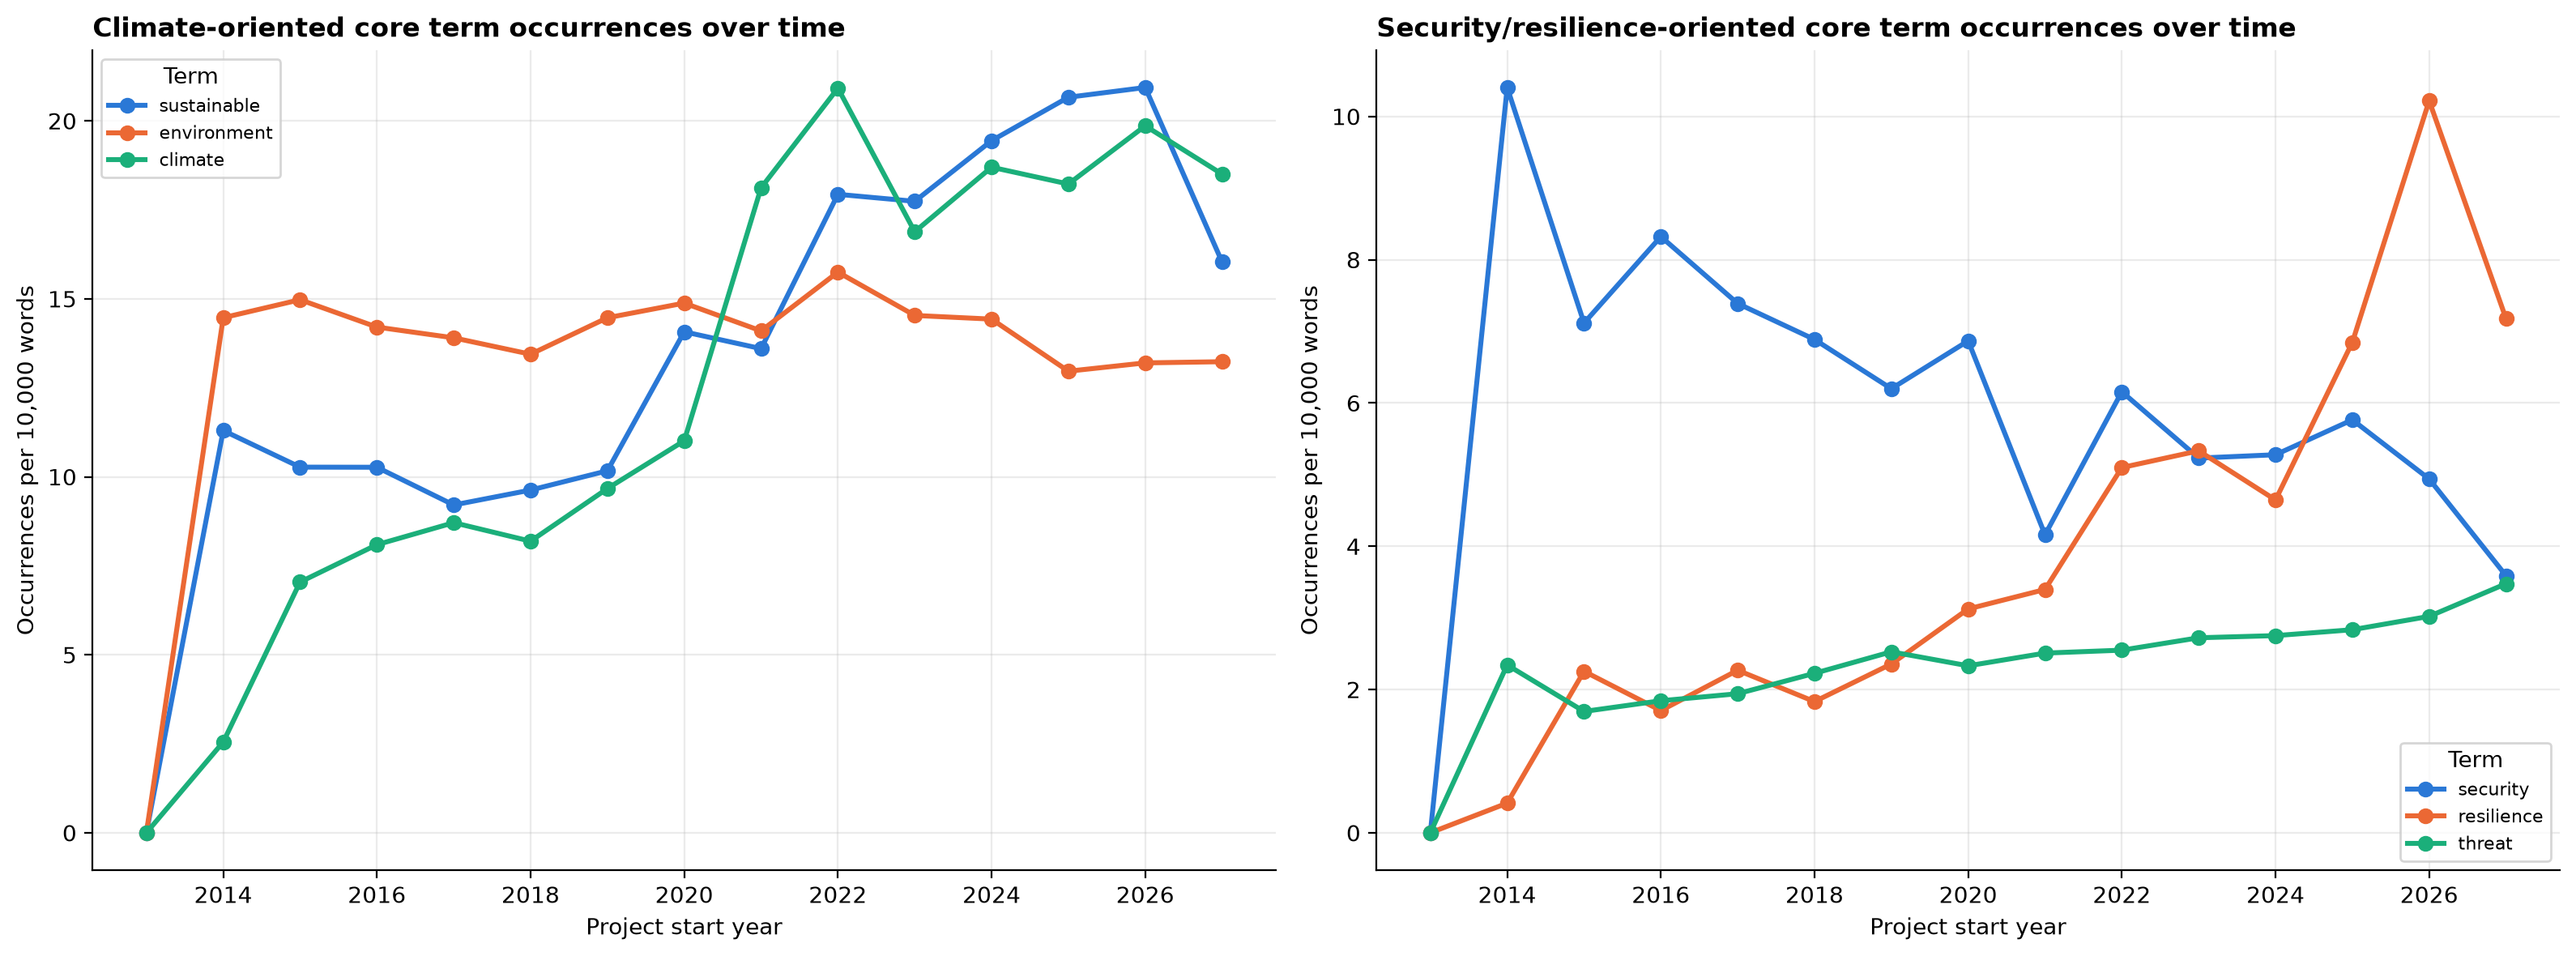

In [9]:
# Inspect a compact set of core terms for each narrative so the plot stays readable.
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False, dpi=200)

for ax, (narrative, narrative_terms) in zip(axes, NARRATIVE_TERMS.items()):
    top_terms = (
        term_frequency[narrative_terms]
        .mean()
        .sort_values(ascending=False)
        .head(3)
        .index.tolist()
    )
    term_frequency[top_terms[0]].plot(ax=ax, marker="o", lw=2.2, color=BLUE)
    term_frequency[top_terms[1]].plot(ax=ax, marker="o", lw=2.2, color=ORANGE)
    term_frequency[top_terms[2]].plot(ax=ax, marker="o", lw=2.2, color=AQUA)
    ax.set_title(f"{narrative} core term occurrences over time", fontweight="bold", loc="left")
    ax.set_xlabel("Project start year")
    ax.set_ylabel("Occurrences per 10,000 words")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25)
    ax.legend(title="Term", fontsize=8)

plt.tight_layout()
plt.show()


#### Robustness check: share of projects mentioning each narrative

Repeated use of a word in a small number of projects could dominate token frequency. The following measure instead counts each project at most once per narrative and reports the percentage of projects that mention at least one dictionary term.

In [10]:
project_mentions = pd.DataFrame(index=data.index)
project_mentions["start_year"] = data["start_year"]

for narrative, terms in NARRATIVE_TERMS.items():
    project_mentions[narrative] = term_counts[terms].sum(axis=1).gt(0)

project_mentions["Both narratives"] = project_mentions[list(NARRATIVE_TERMS)].all(axis=1)

annual_project_share = (
    project_mentions.groupby("start_year")[list(NARRATIVE_TERMS) + ["Both narratives"]]
    .mean()
    .mul(100)
    .loc[included_years]
)


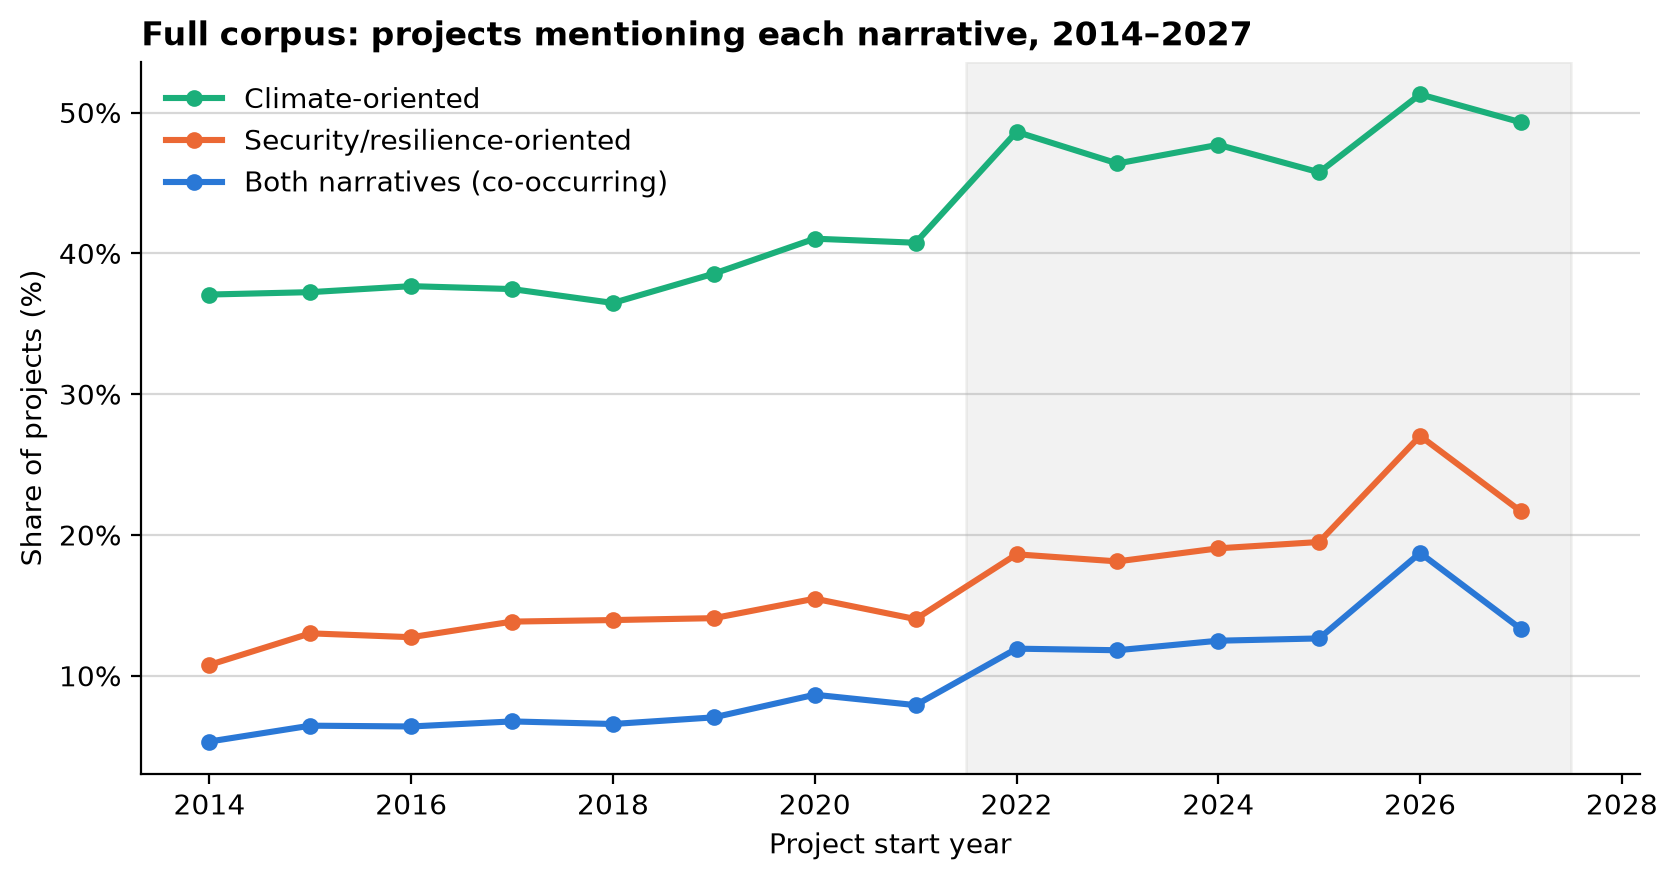

,Climate-oriented,Security/resilience-oriented,Both narratives
start_year,,,
2014,37.07,10.77,5.33
2015,37.24,13.01,6.45
2016,37.67,12.74,6.40
2017,37.46,13.85,6.76
2018,36.48,13.96,6.57
2019,38.56,14.09,7.05
2020,41.04,15.48,8.65
2021,40.75,14.02,7.91
2022,48.63,18.62,11.92


In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.5), dpi=200)
ax.plot(annual_project_share.index, annual_project_share["Climate-oriented"],
        color=AQUA, lw=2.2, marker="o", ms=5, label="Climate-oriented")
ax.plot(annual_project_share.index, annual_project_share["Security/resilience-oriented"],
        color=ORANGE, lw=2.2, marker="o", ms=5, label="Security/resilience-oriented")
ax.plot(annual_project_share.index, annual_project_share["Both narratives"],
        color=BLUE, lw=2.2, marker="o", ms=5, label="Both narratives (co-occurring)")

ax.set_xlabel("Project start year")
ax.set_ylabel("Share of projects (%)")
ax.set_title("Full corpus: projects mentioning each narrative, 2014–2027", loc="left", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.axvspan(2021.5, 2027.5, color=GRAY, alpha=0.1, zorder=0)  # shade post-2022
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.5)
ax.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.savefig("data/full_corpus_narratives.png", dpi=200)
plt.show()

display(annual_project_share.round(2))


# Narrowing down the dataset
The above analysis was performed on the entire corpus of extracted projects of the Horizon2020 and Horizon Europe programmes. Since this thesis only focusses on climate-related projects, the following Bag-of-Words analysis will be performed on the subset of the corpus that relates to climate change.

In [12]:
climate_terms = NARRATIVE_TERMS["Climate-oriented"]
available_climate_terms = [t for t in climate_terms if t in term_counts.columns]
missing_climate_terms = [t for t in climate_terms if t not in term_counts.columns]
if missing_climate_terms:
    print("WARNING: The following climate terms are missing from term_counts and will be ignored:")
    print(missing_climate_terms)

if not available_climate_terms:
    raise RuntimeError("No climate terms are available in term_counts. Check the NARRATIVE_TERMS vocabulary and vectorizer settings.")

climate_mask = term_counts[available_climate_terms].sum(axis=1) > 0
climate_data = data.loc[climate_mask].copy()
climate_corpus = climate_data["_combined_text"].fillna("").astype(str).tolist()

print(f"Climate-related subset size: {len(climate_data):,} projects")
print(f"Selected {len(climate_data) / len(data) * 100:.1f}% of the full corpus")

# Keep the climate subset for the topic modeling stage.
# Later cells can use `climate_data` and `climate_corpus` instead of the full corpus.

Climate-related subset size: 24,827 projects
Selected 42.2% of the full corpus


In [13]:
# Repeat the bag-of-words analysis on the climate subset only.
climate_lemmatized_corpus = [lemmatize_text(doc) for doc in climate_corpus]

climate_count_vec = CountVectorizer(
    min_df=2,
    max_features=500,
)
climate_bow_matrix = climate_count_vec.fit_transform(climate_lemmatized_corpus)
climate_bow_df = pd.DataFrame(
    climate_bow_matrix.toarray(),
    columns=climate_count_vec.get_feature_names_out(),
)
climate_word_freq = climate_bow_df.sum().sort_values(ascending=False)

print("Climate subset word frequency (top 50):")
display(climate_word_freq.head(50))


Climate subset word frequency (top 50):


system           25116
energy           21944
technology       21334
process          15101
sustainable      14428
environment      14390
european         14278
material         13967
climate          13563
impact           12741
environmental    12521
aim              12270
change           12126
innovation       11778
market           10534
develop          10412
eu               10182
europe            9932
industry          9879
network           9861
design            9723
production        9699
innovative        9420
knowledge         9208
application       9100
tool              8948
high              8839
challenge         8833
novel             8518
management        8499
support           8349
service           8339
global            8328
policy            8272
model             8236
water             8190
potential         8015
cell              7921
science           7885
product           7884
health            7842
objective         7793
social            7770
key        

In [14]:
climate_trend_matrix = trend_vectorizer.transform(climate_lemmatized_corpus)
climate_term_counts = pd.DataFrame(
    climate_trend_matrix.toarray(),
    columns=trend_vectorizer.get_feature_names_out(),
    index=climate_data.index,
)
climate_data["token_count"] = [len(document.split()) for document in climate_lemmatized_corpus]
climate_term_counts["start_year"] = climate_data["start_year"]
climate_term_counts["token_count"] = climate_data["token_count"]

available_climate_terms = [t for t in terms if t in climate_term_counts.columns]
missing_climate_terms = [t for t in terms if t not in climate_term_counts.columns]
if missing_climate_terms:
    print("WARNING: The following narrative terms are missing from climate_term_counts and will be ignored in the climate subset analysis:")
    print(missing_climate_terms)
if not available_climate_terms:
    raise RuntimeError("No narrative terms are available in climate_term_counts. Check the NARRATIVE_TERMS vocabulary and vectorizer settings.")

climate_annual_counts = climate_term_counts.groupby("start_year")[available_climate_terms].sum()
climate_annual_tokens = climate_term_counts.groupby("start_year")["token_count"].sum()
climate_annual_projects = climate_data.groupby("start_year").size()
climate_annual_frequency = climate_annual_counts.div(climate_annual_tokens, axis=0) * 10_000
climate_included_years = climate_annual_projects[climate_annual_projects >= MIN_PROJECTS_PER_YEAR].index
climate_annual_frequency = climate_annual_frequency.loc[climate_included_years]

climate_year_summary = pd.DataFrame({
    "projects": climate_annual_projects.loc[climate_included_years],
    "analysed_words": climate_annual_tokens.loc[climate_included_years],
})
display(climate_year_summary)


,projects,analysed_words
start_year,,
2014,327,56751
2015,1806,312468
2016,1937,336740
2017,1802,317202
2018,1942,341135
2019,2118,371791
2020,1883,332476
2021,1514,265217
2022,2504,436456


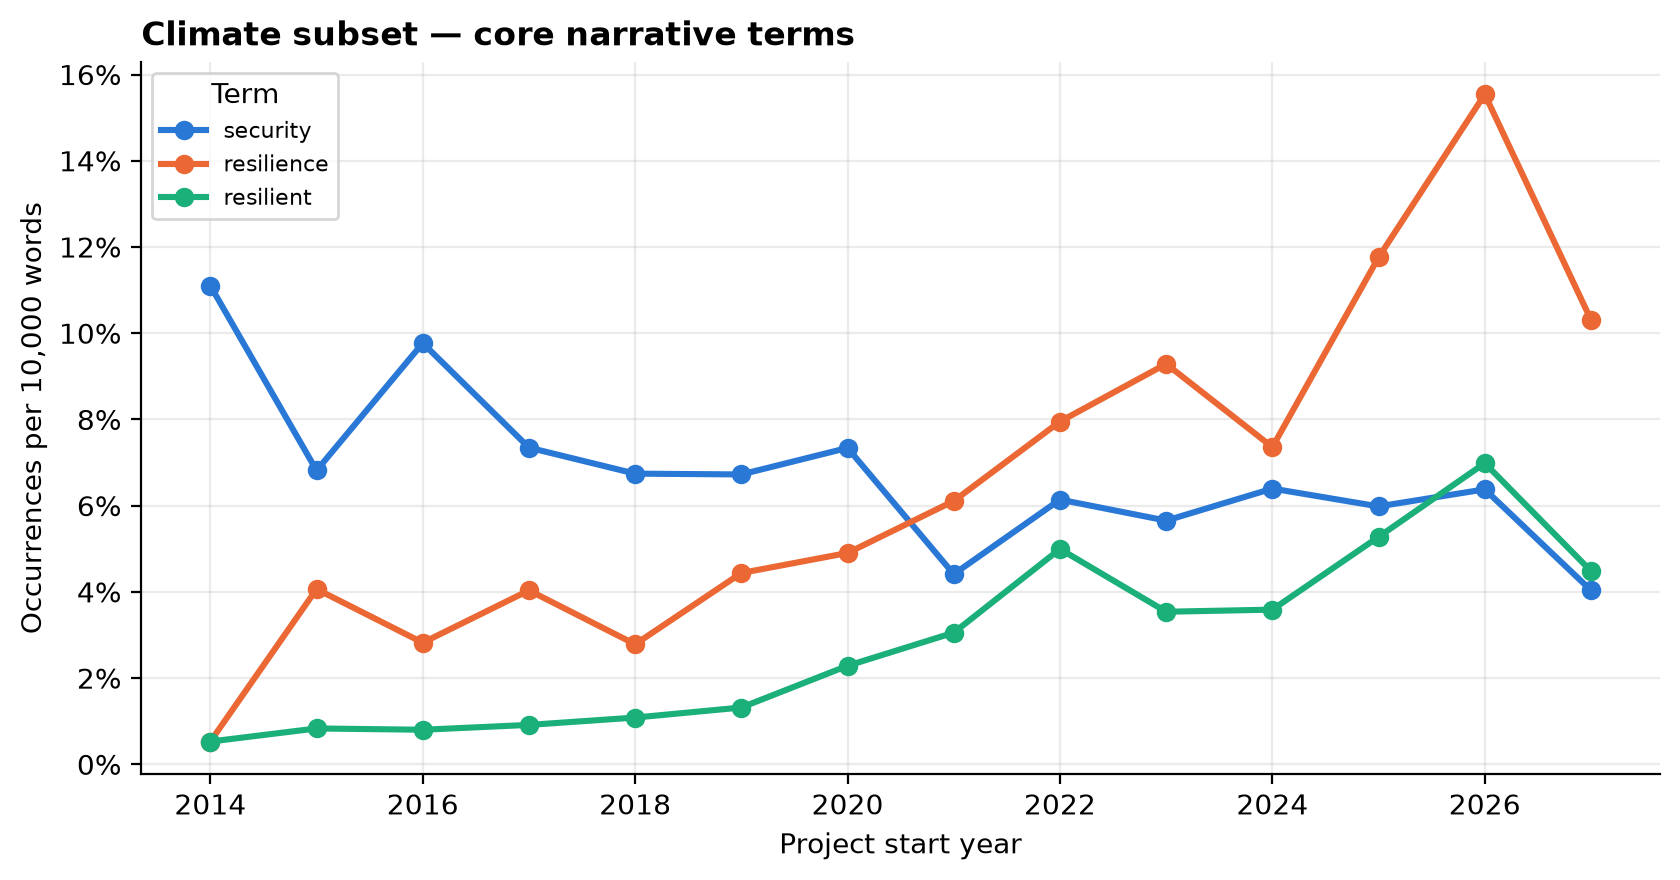

In [15]:
climate_term_frequency = climate_annual_frequency.copy()

fig, ax = plt.subplots(figsize=(8.5, 4.5), dpi=200)
for narrative, narrative_terms in NARRATIVE_TERMS.items():
    available_narrative_terms = [t for t in narrative_terms if t in climate_term_frequency.columns]
    if not available_narrative_terms:
        continue
    top_terms = (
        climate_term_frequency[available_narrative_terms]
        .mean()
        .sort_values(ascending=False)
        .head(3)
        .index.tolist()
    )
    climate_term_frequency[top_terms[0]].plot(ax=ax, marker="o", lw=2.2, color=BLUE)
    climate_term_frequency[top_terms[1]].plot(ax=ax, marker="o", lw=2.2, color=ORANGE)
    climate_term_frequency[top_terms[2]].plot(ax=ax, marker="o", lw=2.2, color=AQUA)

ax.set_title("Climate subset — core narrative terms", loc="left", fontweight="bold")
ax.set_xlabel("Project start year")
ax.set_ylabel("Occurrences per 10,000 words")
ax.grid(alpha=0.25)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(title="Term", fontsize=8)
plt.tight_layout()
plt.show()


In [16]:
climate_project_mentions = pd.DataFrame(index=climate_data.index)
climate_project_mentions["start_year"] = climate_data["start_year"]
for narrative, narrative_terms in NARRATIVE_TERMS.items():
    available_narrative_terms = [t for t in narrative_terms if t in climate_term_counts.columns]
    if not available_narrative_terms:
        climate_project_mentions[narrative] = False
    else:
        climate_project_mentions[narrative] = climate_term_counts[available_narrative_terms].sum(axis=1).gt(0)
climate_project_mentions["Both narratives"] = climate_project_mentions[list(NARRATIVE_TERMS)].all(axis=1)

climate_annual_project_share = (
    climate_project_mentions.groupby("start_year")[list(NARRATIVE_TERMS) + ["Both narratives"]]
    .mean()
    .mul(100)
    .loc[climate_included_years]
)

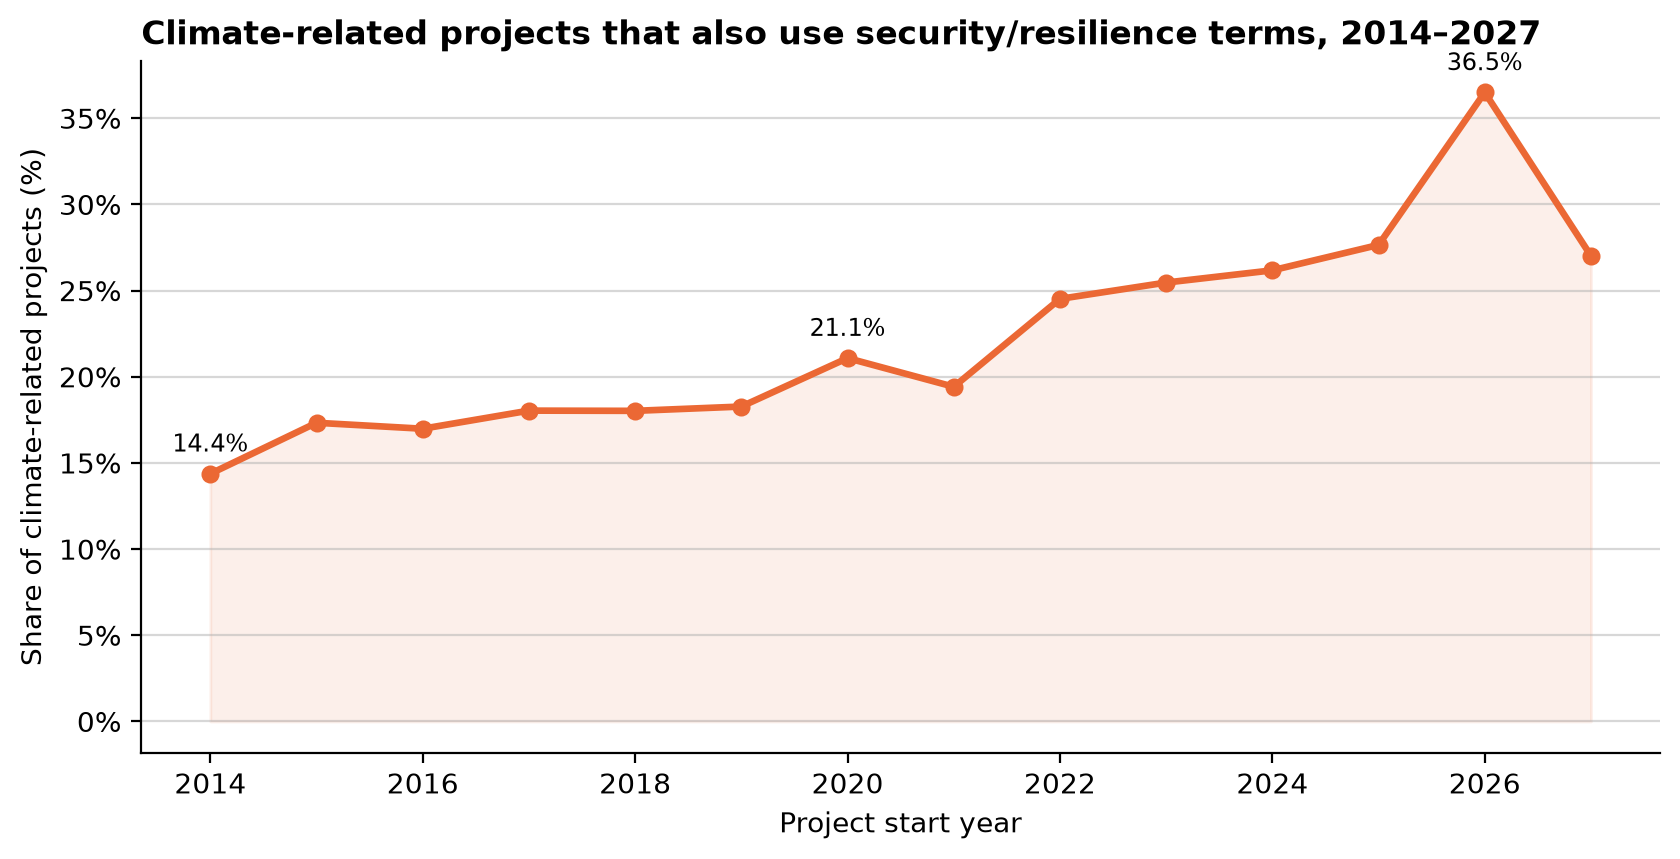

,Climate-oriented,Security/resilience-oriented,Both narratives
start_year,,,
2014,100.0,14.37,14.37
2015,100.0,17.33,17.33
2016,100.0,16.99,16.99
2017,100.0,18.04,18.04
2018,100.0,18.02,18.02
2019,100.0,18.27,18.27
2020,100.0,21.08,21.08
2021,100.0,19.42,19.42
2022,100.0,24.52,24.52


In [17]:
overlap = climate_annual_project_share["Security/resilience-oriented"]  # = "Both narratives" here, since climate = 100%

fig, ax = plt.subplots(figsize=(8.5, 4.4), dpi=200)
ax.plot(overlap.index, overlap.values, color=ORANGE, lw=2.4, marker="o", ms=5.5)
ax.fill_between(overlap.index, overlap.values, color=ORANGE, alpha=0.1)

ax.set_xlabel("Project start year")
ax.set_ylabel("Share of climate-related projects (%)")
ax.set_title("Climate-related projects that also use security/resilience terms, 2014–2027",
             loc="left", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.5)

for year in (2014, 2020, 2026):
    if year in overlap.index:
        y = overlap.loc[year]
        ax.annotate(f"{y:.1f}%", (year, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8.5)

plt.tight_layout()
plt.savefig("data/climate_subset_overlap.png", dpi=200)
plt.show()

display(climate_annual_project_share.round(2))


## BERTopic 

### BERTopic set-up and sample validation

This section tests BERTopic on a small random subset of documents before scaling to the full corpus.

In [18]:
required_packages = [
    "bertopic",
    "sentence-transformers",
    "umap-learn",
    "hdbscan",
]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    print("Installing missing BERTopic dependencies:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All BERTopic dependencies are already installed.")

Installing missing BERTopic dependencies: ['sentence-transformers', 'umap-learn']


In [19]:
corpus_raw = climate_corpus
print(f"Climate subset size: {len(corpus_raw):,} documents")

sample_size = min(500, len(corpus_raw))  # smaller test sample for faster validation
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(corpus_raw), size=sample_size, replace=False)
sample_texts = [corpus_raw[i] for i in sample_idx]

print(f"Using sample_size={sample_size} for the initial BERTopic test on the climate subset")

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

sample_topic_model = BERTopic(
    language="english",
    embedding_model=embedding_model,
    umap_model=UMAP(
        n_neighbors=20,
        n_components=5,
        metric="cosine",
        random_state=42,
    ),
    hdbscan_model=HDBSCAN(
        min_cluster_size=5,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    ),
    min_topic_size=5,
    verbose=True,
)

sample_topics, sample_probs = sample_topic_model.fit_transform(sample_texts)
print(f"Sample BERTopic test finished. Extracted {len(sample_topic_model.get_topic_info()) - 1} valid topics.")

Climate subset size: 24,827 documents
Using sample_size=500 for the initial BERTopic test on the climate subset


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2480.54it/s]
2026-08-29 10:12:48,277 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 16/16 [00:40<00:00,  2.52s/it]
2026-08-29 10:13:28,602 - BERTopic - Embedding - Completed ✓
2026-08-29 10:13:28,603 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-29 10:13:41,636 - BERTopic - Dimensionality - Completed ✓
2026-08-29 10:13:41,637 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-29 10:13:41,664 - BERTopic - Cluster - Completed ✓
2026-08-29 10:13:41,670 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-29 10:13:41,791 - BERTopic - Representation - Completed ✓


Sample BERTopic test finished. Extracted 18 valid topics.


In [20]:
# Review the sample topics and document distribution.
topic_info = sample_topic_model.get_topic_info()
display(topic_info.head(25))

topic_counts = pd.Series(sample_topics).value_counts().rename_axis("Topic").reset_index(name="Document count")
display(topic_counts.head(10))

print("Example topic keywords:")
for topic_num in topic_info[topic_info.Topic >= 0]["Topic"].head(5):
    print(f"\nTopic {topic_num}:")
    print(sample_topic_model.get_topic(topic_num))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,177,-1_energy_environmental_systems_sustainable,"[energy, environmental, systems, sustainable, ...",[nexus framework biodiversityrelevant transfor...
1,0,72,0_innovation_science_policy_european,"[innovation, science, policy, european, cultur...",[4itraction innovation investment infrastructu...
2,1,33,1_food_production_sustainable_waste,"[food, production, sustainable, waste, innovat...",[building interoperable datadriven innovative ...
3,2,25,2_hydrogen_co2_waste_green,"[hydrogen, co2, waste, green, energy, battery,...",[technologies strategies fuel cells hydrogen t...
4,3,23,3_energy_wind_power_storage,"[energy, wind, power, storage, offshore, syste...",[solar energy 24 hours yearround offgrid hydro...
5,4,22,4_computing_robots_ai_decision,"[computing, robots, ai, decision, intelligence...",[flexibilization complex ecosystems democratic...
6,5,20,5_climate_ice_sediment_sea,"[climate, ice, sediment, sea, change, models, ...",[genetic view past sea ice variability arctic ...
7,6,17,6_quantum_materials_properties_2d,"[quantum, materials, properties, 2d, physics, ...",[understanding designing inorganic materials p...
8,7,17,7_drug_spinal_cell_sma,"[drug, spinal, cell, sma, cancer, disease, mir...",[novel human neurodegenerative disease specifi...
9,8,16,8_health_care_patient_safety,"[health, care, patient, safety, training, clin...",[health economics policy impact hepi health ec...


,Topic,Document count
0,-1,177
1,0,72
2,1,33
3,2,25
4,3,23
5,4,22
6,5,20
7,6,17
8,7,17
9,8,16


Example topic keywords:

Topic 0:
[('innovation', np.float64(0.025428164325608918)), ('science', np.float64(0.0189504082686837)), ('policy', np.float64(0.016537900120207717)), ('european', np.float64(0.016096952347309047)), ('cultural', np.float64(0.015550644980868479)), ('inclusive', np.float64(0.01448417896008061)), ('researchers', np.float64(0.014203779279801777)), ('europe', np.float64(0.013883105064100171)), ('eu', np.float64(0.013730831241844516)), ('sustainable', np.float64(0.013724660224916642))]

Topic 1:
[('food', np.float64(0.0492788511314729)), ('production', np.float64(0.03844239533732104)), ('sustainable', np.float64(0.027872919346321145)), ('waste', np.float64(0.022882762031343876)), ('innovative', np.float64(0.020014256351801825)), ('value', np.float64(0.01971114592019961)), ('biomass', np.float64(0.019226520188829924)), ('products', np.float64(0.018562421892666374)), ('market', np.float64(0.01746631434567295)), ('feed', np.float64(0.01659991463624722))]

Topic 2:
[('hy

In [ ]:
# Visualize the top sample topics.
sample_topic_model.visualize_barchart(top_n_topics=12, n_words=10, width=800, height=400)

### Fitting BERTopic on the full corpus after sample succeeds

In [22]:
full_topic_model = BERTopic(
    language="english",
    embedding_model=embedding_model,
    umap_model=UMAP(
        n_neighbors=20,
        n_components=5,
        metric="cosine",
        random_state=42,
    ),
    hdbscan_model=HDBSCAN(
        min_cluster_size=5,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    ),
    min_topic_size=5,
    verbose=True,
)


full_topics, full_probs = full_topic_model.fit_transform(corpus_raw)

full_topic_info = full_topic_model.get_topic_info()
display(full_topic_info.head(20))

2026-08-29 10:13:42,803 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 776/776 [32:15<00:00,  2.49s/it]
2026-08-29 10:45:58,442 - BERTopic - Embedding - Completed ✓
2026-08-29 10:45:58,444 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-29 10:46:46,385 - BERTopic - Dimensionality - Completed ✓
2026-08-29 10:46:46,387 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-29 10:46:53,613 - BERTopic - Cluster - Completed ✓
2026-08-29 10:46:53,627 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-29 10:46:58,271 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,11033,-1_environmental_sustainable_european_climate,"[environmental, sustainable, european, climate...",[integrated modular power conversion renewable...
1,0,344,0_battery_batteries_electrolyte_lithium,"[battery, batteries, electrolyte, lithium, ele...",[semisolid polymer electrolyte enabling afford...
2,1,274,1_species_evolutionary_ecology_biodiversity,"[species, evolutionary, ecology, biodiversity,...",[realised ecological niche species distributio...
3,2,267,2_grid_grids_electricity_power,"[grid, grids, electricity, power, flexibility,...",[interoperable tools efficient management effe...
4,3,255,3_brain_neural_sensory_visual,"[brain, neural, sensory, visual, neurons, cort...",[understanding diversity decision strategy neu...
5,4,178,4_coastal_marine_ocean_seas,"[coastal, marine, ocean, seas, sea, atlantic, ...",[aqua infrastructure services health protectio...
6,5,173,5_heat_cooling_heating_thermal,"[heat, cooling, heating, thermal, storage, csp...",[efficient compact modular thermal energy stor...
7,6,172,6_night_researchers_science_schools,"[night, researchers, science, schools, public,...",[european researchers night night deal night d...
8,7,165,7_quantum_superconducting_qubits_manybody,"[quantum, superconducting, qubits, manybody, t...",[quantum probes complex systems verge scientif...
9,8,146,8_wastewater_treatment_water_sludge,"[wastewater, treatment, water, sludge, sewage,...",[wastewater treatment efficient reactors integ...


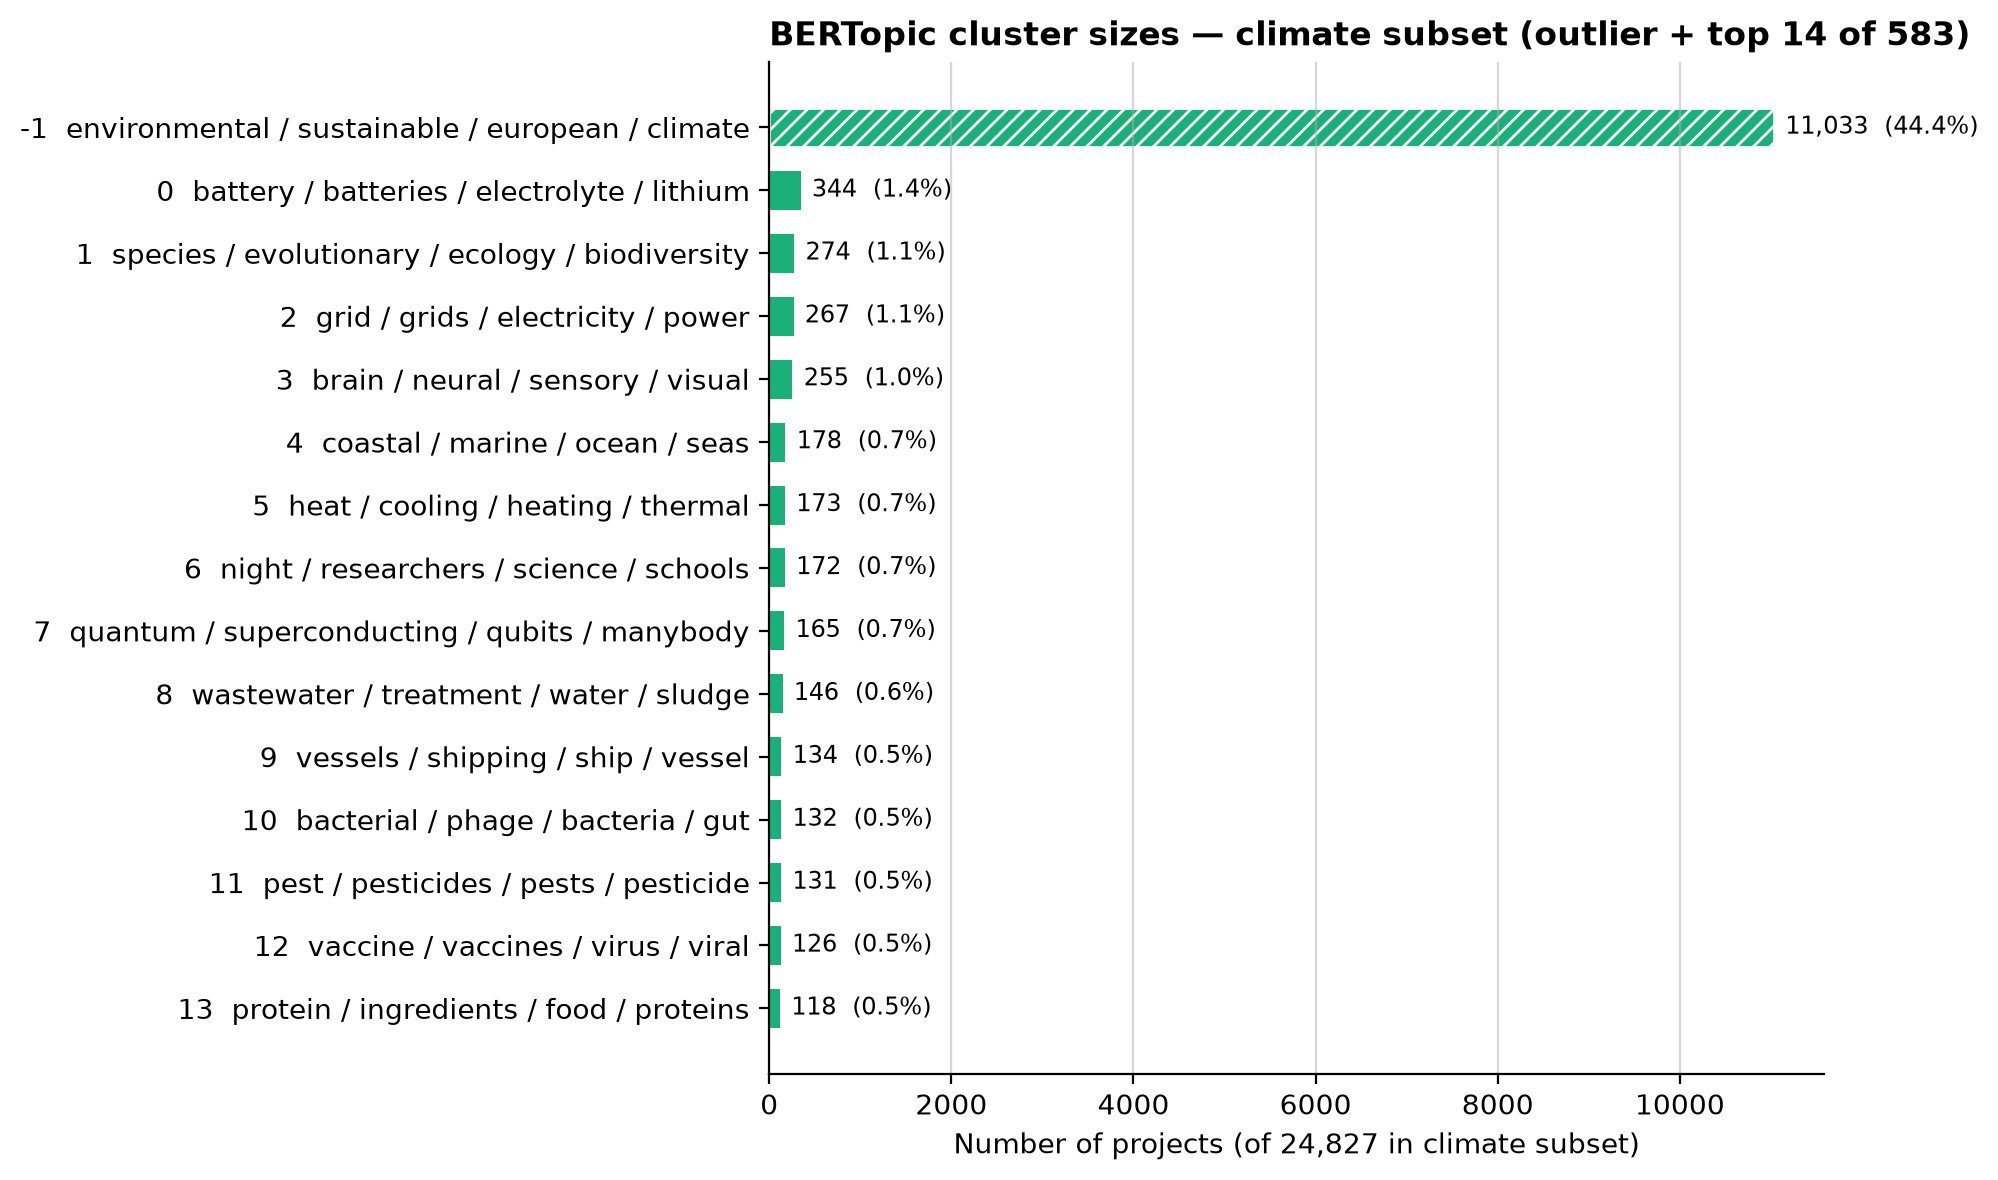

In [23]:
N_NAMED = 14
topic_sizes = full_topic_info.sort_values("Count", ascending=False)
outlier_row = topic_sizes[topic_sizes["Topic"] == -1]
named_rows = topic_sizes[topic_sizes["Topic"] != -1].head(N_NAMED)
plot_rows = pd.concat([outlier_row, named_rows]).iloc[::-1]

total_docs = len(corpus_raw)
n_topics = len(full_topic_info) - 1  # matches "valid topics" count

labels = [f"{row.Topic}  " + row.Name.split("_", 1)[1].replace("_", " / ") for row in plot_rows.itertuples()]
counts = plot_rows["Count"].values
is_outlier = (plot_rows["Topic"] == -1).values
colors = [GRAY if flag else BLUE for flag in is_outlier]

fig, ax = plt.subplots(figsize=(10.0, 6.0), dpi=200)
bars = ax.barh(labels, counts, color=AQUA, height=0.62)
for bar, flag in zip(bars, is_outlier):
    if flag:
        bar.set_hatch("////")
        bar.set_edgecolor("#fcfcfb")

for i, count in enumerate(counts):
    pct = count / total_docs * 100
    ax.text(count + total_docs * 0.005, i, f"{count:,}  ({pct:.1f}%)", va="center", fontsize=8.5)

ax.set_xlabel(f"Number of projects (of {total_docs:,} in climate subset)")
ax.set_title(f"BERTopic cluster sizes — climate subset (outlier + top {N_NAMED} of {n_topics})",
             loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.5)
plt.tight_layout()
plt.savefig("data/bertopic_sizes.png", dpi=200)
plt.show()

In [24]:
full_topic_model.visualize_barchart(top_n_topics=20, n_words=10, width=800, height=400)


### Year-by-year BERTopic comparison

This section compares topic distributions across years using the full BERTopic model results. It assumes `full_topic_model` and `full_topics` are available after running the full corpus fit.

In [25]:
if "full_topic_model" not in globals() or "full_topics" not in globals():
    raise RuntimeError(
        "Run the full BERTopic fit cell first to create `full_topic_model` and `full_topics` before executing this comparison section."
    )

if "full_topic_info" not in globals():
    full_topic_info = full_topic_model.get_topic_info()

# Combine year metadata with assigned topics from the climate subset used to fit BERTopic.
assigned_topics = pd.Series(full_topics, index=climate_data.index)
bertopic_year_df = pd.DataFrame({
    "start_year": climate_data["start_year"],
    "topic": assigned_topics,
})
bertopic_year_df = bertopic_year_df[bertopic_year_df["start_year"].notna()].copy()
bertopic_year_df["start_year"] = bertopic_year_df["start_year"].astype(int)

MIN_DOCS_PER_YEAR = 30
valid_years = (
    bertopic_year_df.groupby("start_year").size().loc[lambda s: s >= MIN_DOCS_PER_YEAR].index
)
bertopic_year_df = bertopic_year_df[bertopic_year_df["start_year"].isin(valid_years)]

if bertopic_year_df.empty:
    raise RuntimeError("No years remain after filtering for minimum document count. Lower MIN_DOCS_PER_YEAR or inspect the data.")

year_counts = bertopic_year_df.groupby("start_year").size().rename("year_count")
topic_year_counts = (
    bertopic_year_df.groupby(["start_year", "topic"]).size().rename("count").reset_index()
)
topic_year_counts = topic_year_counts.merge(year_counts, on="start_year")
topic_year_counts["share_pct"] = topic_year_counts["count"] / topic_year_counts["year_count"] * 100

topic_name_map = dict(zip(full_topic_info.Topic, full_topic_info.Name))
topic_year_counts["topic_name"] = topic_year_counts["topic"].map(topic_name_map).fillna("Other")

# Show the top topics for each year.
top_by_year = (
    topic_year_counts.sort_values(["start_year", "share_pct"], ascending=[True, False])
    .groupby("start_year")
    .head(5)
    .reset_index(drop=True)
)

display(top_by_year[["start_year", "topic", "topic_name", "count", "year_count", "share_pct"]].round({"share_pct": 2}))

,start_year,topic,topic_name,count,year_count,share_pct
0,2014,-1,-1_environmental_sustainable_european_climate,151,327,46.18
1,2014,21,21_smes_innovation_sme_instrument,26,327,7.95
2,2014,2,2_grid_grids_electricity_power,10,327,3.06
3,2014,6,6_night_researchers_science_schools,7,327,2.14
4,2014,31,31_robot_robots_manipulation_robotic,4,327,1.22
...,...,...,...,...,...,...
65,2027,-1,-1_environmental_sustainable_european_climate,103,248,41.53
66,2027,75,75_pathogen_immunity_plant_effectors,5,248,2.02
67,2027,0,0_battery_batteries_electrolyte_lithium,4,248,1.61
68,2027,1,1_species_evolutionary_ecology_biodiversity,4,248,1.61


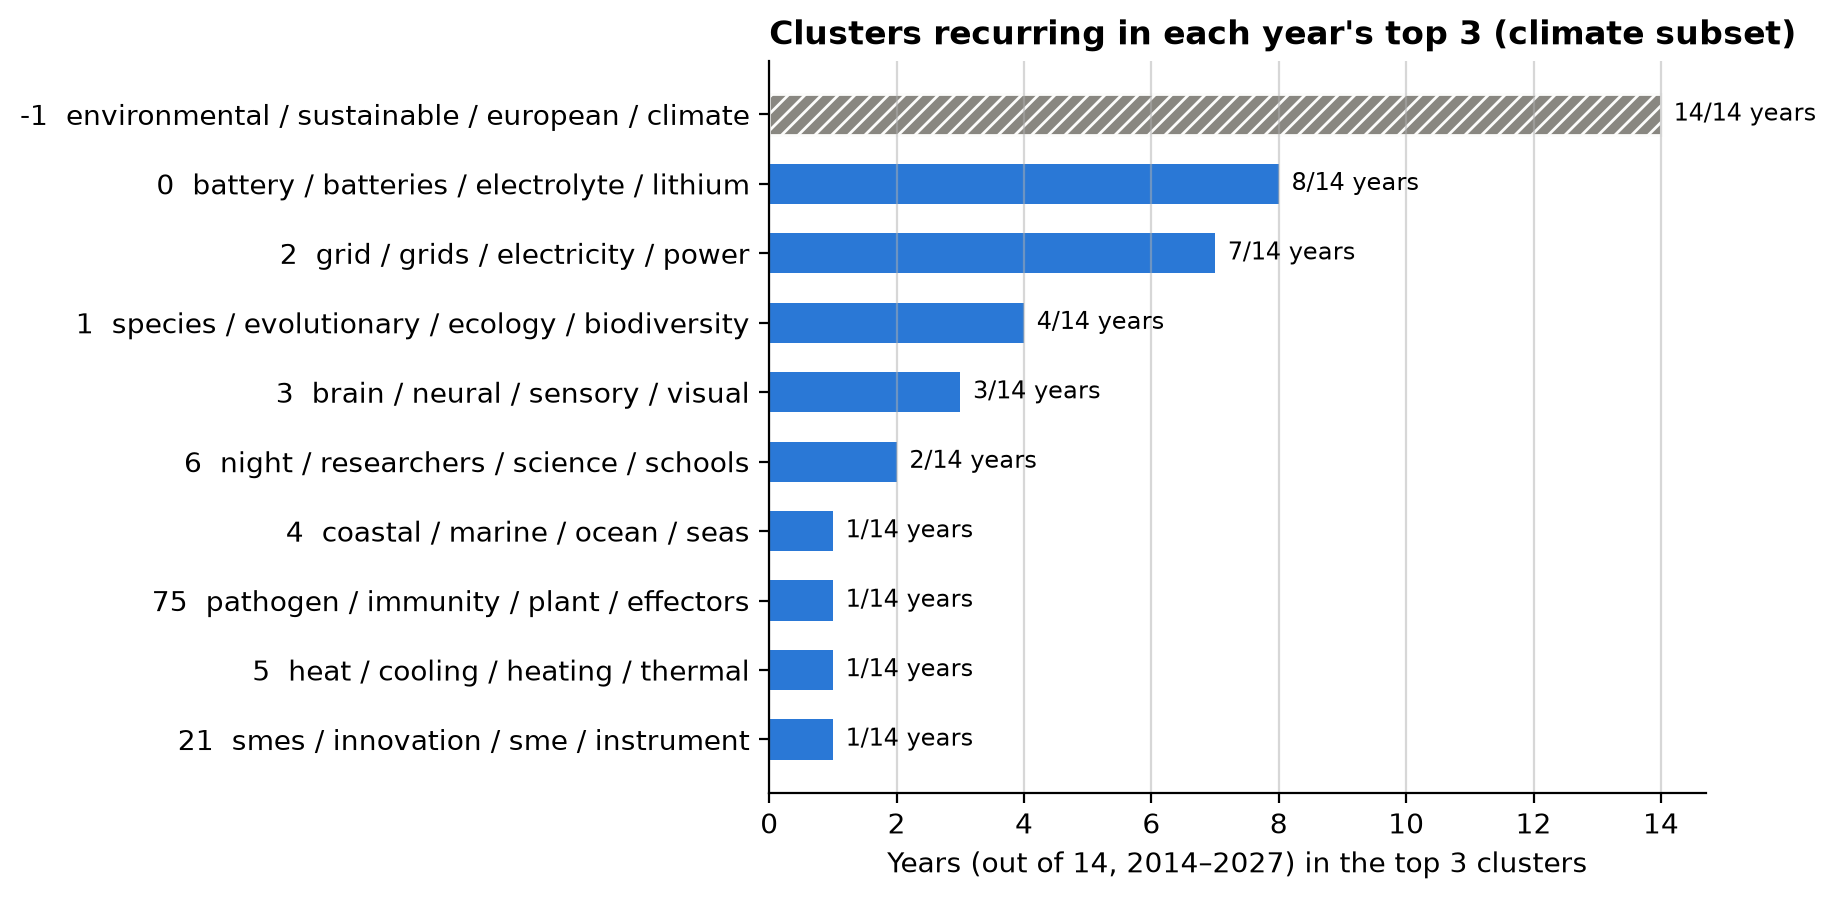

In [26]:
TOP_N = 3
top3_by_year = (
    topic_year_counts.sort_values(["start_year", "share_pct"], ascending=[True, False])
    .groupby("start_year")
    .head(TOP_N)
)

n_years = topic_year_counts["start_year"].nunique()
freq_df = (
    top3_by_year["topic"].value_counts()
    .rename_axis("topic").reset_index(name="years_in_top3")
)
freq_df["topic_name"] = freq_df["topic"].map(topic_name_map)
freq_df = freq_df.sort_values("years_in_top3")  # ascending, so largest bar ends up at the top

labels = [f"{row.topic}  " + row.topic_name.split("_", 1)[1].replace("_", " / ") for row in freq_df.itertuples()]
values = freq_df["years_in_top3"].values
is_outlier = (freq_df["topic"] == -1).values
colors = [GRAY if flag else BLUE for flag in is_outlier]

fig, ax = plt.subplots(figsize=(9.2, 4.6), dpi=200)
bars = ax.barh(labels, values, color=colors, height=0.58)
for bar, flag in zip(bars, is_outlier):
    if flag:
        bar.set_hatch("////")
        bar.set_edgecolor("#fcfcfb")

for i, v in enumerate(values):
    ax.text(v + 0.2, i, f"{v}/{n_years} years", va="center", fontsize=8.5)

ax.set_xlabel(f"Years (out of {n_years}, {min(valid_years)}–{max(valid_years)}) in the top {TOP_N} clusters")
ax.set_title(f"Clusters recurring in each year's top {TOP_N} (climate subset)", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.5)
plt.tight_layout()
plt.savefig("data/bertopic_top3_frequency.png", dpi=200)
plt.show()

In [51]:
# Visualize the strongest topics across years.
TOP_N_TOPICS = 12
popular_topics = (
    topic_year_counts.groupby("topic")
    ["share_pct"].mean()
    .nlargest(TOP_N_TOPICS)
    .index
)
plot_df = topic_year_counts[topic_year_counts["topic"].isin(popular_topics)].copy()
plot_df["topic_label"] = plot_df.apply(
    lambda row: f"{row.topic} — {row.topic_name}", axis=1
)

fig = px.bar(
    plot_df,
    x="start_year",
    y="share_pct",
    color="topic_label",
    title=f"Top {TOP_N_TOPICS} BERTopic clusters by year",
    labels={"share_pct": "Share of documents (%)", "start_year": "Project start year"},
    category_orders={"start_year": sorted(valid_years)},
)
fig.update_layout(barmode="stack", legend_title_text="Topic")
fig.update_layout(width=1400, height=600)
fig.write_image("data/bertopic_top12_by_year.png", width=1400, height=600, scale=2)
fig.show()

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


In [52]:
# Same graph without the outlier cluster (-1) to focus on the named topics.

topic_year_counts_no_outlier = topic_year_counts[topic_year_counts["topic"] != -1].copy()

popular_topics = (
    topic_year_counts_no_outlier.groupby("topic")
    ["share_pct"].mean()
    .nlargest(TOP_N_TOPICS)
    .index
)
plot_df = topic_year_counts_no_outlier[topic_year_counts_no_outlier["topic"].isin(popular_topics)].copy()
plot_df["topic_label"] = plot_df.apply(
    lambda row: f"{row.topic} — {row.topic_name}", axis=1
)

fig = px.bar(
    plot_df,
    x="start_year",
    y="share_pct",
    color="topic_label",
    title=f"Top {TOP_N_TOPICS} BERTopic clusters by year without outlier (-1)",
    labels={"share_pct": "Share of documents (%)", "start_year": "Project start year"},
    category_orders={"start_year": sorted(valid_years)},
)
fig.update_layout(barmode="stack", legend_title_text="Topic")
fig.update_layout(width=1400, height=600)
fig.write_image("data/bertopic_top12_by_year_no_outlier.png", width=1400, height=600, scale=2)
fig.show()

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


#### Topic trends across years

This line plot shows how the share of the top BERTopic clusters changes year by year.

In [53]:
line_df = plot_df.copy().sort_values(["topic", "start_year"])
fig = px.line(
    line_df,
    x="start_year",
    y="share_pct",
    color="topic_label",
    title=f"Yearly evolution of top {TOP_N_TOPICS} BERTopic clusters",
    labels={"share_pct": "Share of documents (%)", "start_year": "Project start year"},
    category_orders={"start_year": sorted(valid_years)},
)
fig.update_traces(mode="lines+markers")
fig.update_layout(legend_title_text="Topic", hovermode="closest")
fig.update_layout(width=1400, height=600)
fig.write_image("data/yearly_evolution_top12_bertopic.png", width=1400, height=600, scale=2)
fig.show()

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


In [54]:
# Same line chart without the outlier cluster (-1) to focus on the named topics.
line_df = topic_year_counts_no_outlier[topic_year_counts_no_outlier["topic"].isin(popular_topics)].copy()
line_df = line_df.sort_values(["topic", "start_year"])
fig = px.line(
    line_df,
    x="start_year",
    y="share_pct",
    color="topic_name",
    title=f"Yearly evolution of top {TOP_N_TOPICS} BERTopic clusters without outlier (-1)",
    labels={"share_pct": "Share of documents (%)", "start_year": "Project start year"},
    category_orders={"start_year": sorted(valid_years)},
)
fig.update_traces(mode="lines+markers")
fig.update_layout(legend_title_text="Topic", hovermode="closest")
fig.update_layout(width=1400, height=600)
fig.write_image("data/yearly_evolution_top12_bertopic_no_outlier.png", width=1400, height=600, scale=2)
fig.show()

Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


### Representative documents per topic and year

The next cell extracts a few documents for the top topics in each year. This helps interpret the topic labels and check whether the same topic themes persist across years.

In [29]:
EXAMPLE_DOCS_PER_TOPIC = 2
representative_docs = []

for year in sorted(valid_years):
    top_topics = (
        topic_year_counts[topic_year_counts["start_year"] == year]
        .sort_values("share_pct", ascending=False)
        .head(3)["topic"]
        .tolist()
    )
    for topic in top_topics:
        subset = climate_data.loc[(climate_data["start_year"] == year) & (assigned_topics == topic), "_combined_text"]
        sample_texts = subset.dropna().astype(str).tolist()[:EXAMPLE_DOCS_PER_TOPIC]
        representative_docs.append({
            "year": year,
            "topic": topic,
            "topic_name": topic_name_map.get(topic, "Other"),
            "examples": sample_texts,
        })

for entry in representative_docs:
    print(f"Year {entry['year']} — Topic {entry['topic']} — {entry['topic_name']}")
    for i, example in enumerate(entry["examples"], 1):
        print(f'Example {i}: {example[:320]}')
    print("\n" + "-" * 80 + "\n")

Year 2014 — Topic -1 — -1_environmental_sustainable_european_climate
Example 1: energyefficient control internetofthings connected home connected home helps reduce energy costs preserving comfort occupants encontrolintuo leverages internetofthings integrates selflearning adjusting capabilities interacting climate system wall units central heating air conditioning radiators added service encontrol 
Example 2: fast costeffective combined remediation technology elimination chlorinated hydrocarbons soil business company ieg technologie gmbh soil remediation groundwater circulation technologies groundcleaner proposal addresses increase competitiveness developing disruptive rapid costeffective remediate soils contaminated chlori

--------------------------------------------------------------------------------

Year 2014 — Topic 21 — 21_smes_innovation_sme_instrument
Example 1: innovation support network east mediterranean aim become true onestopshop business innovation support along entire v